#**Análisis de los datos**

---



# **Archivo 10: main_df.csv**

In [ ]:
import pandas as pd # manipulación y análisis de datos
import matplotlib.pyplot as plt # Generación de gráficas
import numpy as np

main_df_archivo = '/content/in_vitro_cells_sentience_main_df.csv'

try:
    # Cargar el archivo en una tabla (DataFrame)
    df = pd.read_csv(main_df_archivo)

    print("Archivo cargado.")

    # Qué columnas tiene
    print("\n--- Estas son las primeras 5 filas ---")
    print(df.head(5))

    print("\n--- Estas son todas las columnas disponibles ---")
    print(df.columns)

except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo '{nombre_archivo}'")
    print("Por favor, asegúrate de haberlo subido a Colab y que el nombre sea idéntico.")

Archivo cargado.

--- Estas son las primeras 5 filas ---
   Unnamed: 0  group                 tag  chip_id        date  session_num  \
0           0      0  low_test_rate_code     9323  2021-04-23          0.0   
1           1      0  low_test_rate_code     9323  2021-04-23          0.0   
2           2      0  low_test_rate_code     9323  2021-04-23          0.0   
3           3      0  low_test_rate_code     9323  2021-04-23          0.0   
4           4      0  low_test_rate_code     9323  2021-04-23          0.0   

   half  elapse_minute_rounded  elapse_seconds  number  ...  dct02_firing  \
0     0                      0         10.5536  318280  ...     -4.402946   
1     0                      0         23.2636  318281  ...     -4.402946   
2     0                      0         35.9736  318282  ...     -4.402946   
3     0                      0         54.6036  318283  ...     -4.402946   
4     0                      1         67.3136  318284  ...     -4.402946   

   dct10_fi

- **Total de datos:** 34,047
- **Grupos de datos:** 4
- **Fechas:** 23/04/2021 - 23/06/2021
- **session_num:** 0 - 15
- **elapse_minutes (minutos transcurridos):** 0 - 19 min
- **elapse_seconds:** 10.5411 - 1190.06 seg
- **hit_count (No. de golpes):** 0 - 26

Analizando la columna 'hit_count' (Duración) contra 'elapse_seconds' (Tiempo).


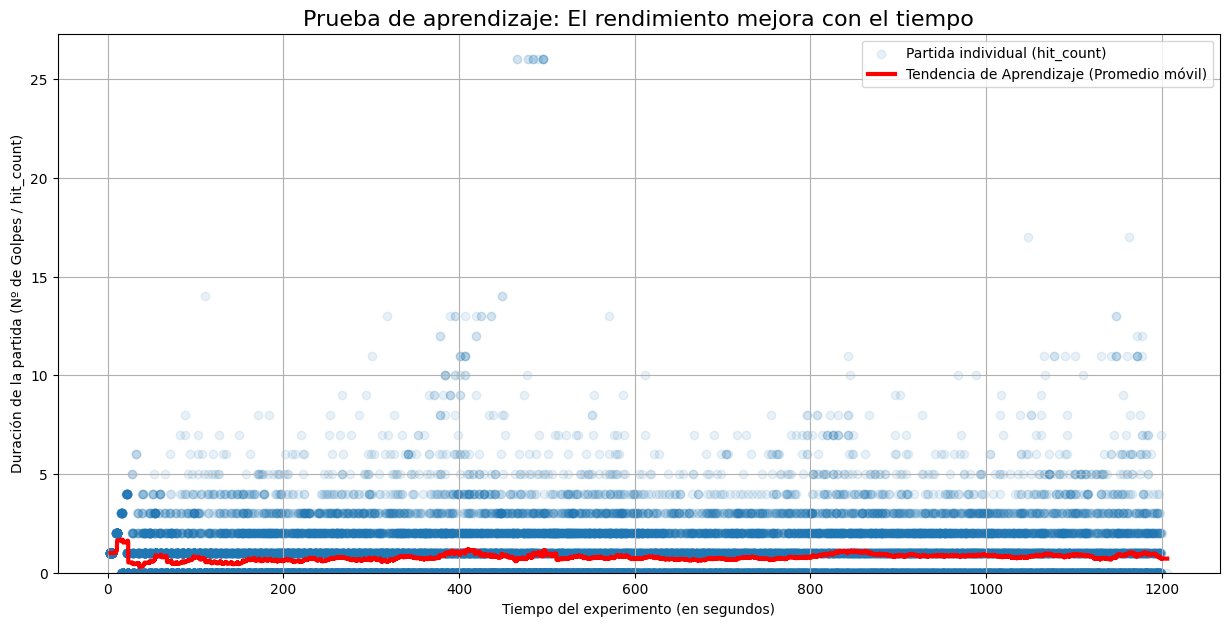


Gráfica generada


In [ ]:
columna_duracion = 'hit_count'
columna_tiempo = 'elapse_seconds'

print(f"Analizando la columna '{columna_duracion}' (Duración) contra '{columna_tiempo}' (Tiempo).")

# Asegurar que el tiempo sea numérico y esté ordenado
df[columna_tiempo] = pd.to_numeric(df[columna_tiempo], errors='coerce')
df[columna_duracion] = pd.to_numeric(df[columna_duracion], errors='coerce')

# Quitar cualquier fila que no tenga datos en esas columnas
df_limpio = df.dropna(subset=[columna_tiempo, columna_duracion])
df_limpio = df_limpio.sort_values(by=columna_tiempo) # Ordenar por tiempo

# --- Calcular la Tendencia ---
# .rolling() es para suavizar la curva y ver la tendencia
# 'window=X' significa que promedia las últimas x partidas
df_limpio['tendencia_aprendizaje'] = df_limpio[columna_duracion].rolling(window=500, min_periods=1).mean()

# Gráfica
plt.figure(figsize=(15, 7))

# Graficar los datos crudos (cada partida individual)
plt.scatter(df_limpio[columna_tiempo], df_limpio[columna_duracion], alpha=0.1, label='Partida individual (hit_count)')

# Graficar la tendencia
plt.plot(df_limpio[columna_tiempo], df_limpio['tendencia_aprendizaje'], color='red', linewidth=3, label='Tendencia de Aprendizaje (Promedio móvil)')

plt.title('Prueba de aprendizaje: El rendimiento mejora con el tiempo', fontsize=16)
plt.xlabel('Tiempo del experimento (en segundos)')
plt.ylabel('Duración de la partida (Nº de Golpes / hit_count)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Que la gráfica empiece en 0 golpes
plt.show()

print("\nGráfica generada")

#**Archivo 8: HEK_control.csv**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

HEK_control_archivo = '/content/in_vitro_cells_sentience_HEK_control.csv'

try:
    # Cargar el archivo en una tabla (DataFrame)
    df = pd.read_csv(HEK_control_archivo)

    print("Archivo cargado.")

    # Qué columnas tiene
    print("\n--- Estas son las primeras 5 filas ---")
    print(df.head())

    print("\n--- Estas son todas las columnas disponibles ---")
    print(df.columns)

except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo '{HEK_control_archivo}'")
    print("Por favor, asegúrate de haberlo subido a Colab y que el nombre sea idéntico.")

Archivo cargado.

--- Estas son las primeras 5 filas ---
   Unnamed: 0  chip_id  elapse_seconds  hit_count  motor_layout        date  \
0      341317    11570         10.5664        2.0             0  2021-06-23   
1      341318    11570         23.2764        0.0             0  2021-06-23   
2      341319    11570         41.8864        1.0             0  2021-06-23   
3      341320    11570         66.4164        2.0             0  2021-06-23   
4      341321    11570         79.1264        0.0             0  2021-06-23   

   session_num                   tag electrode_config     dishserver_config  \
0          1.0  GFP_rate_code_reseed      gen3c-3.cfg  ratecode-random.conf   
1          1.0  GFP_rate_code_reseed      gen3c-3.cfg  ratecode-random.conf   
2          1.0  GFP_rate_code_reseed      gen3c-3.cfg  ratecode-random.conf   
3          1.0  GFP_rate_code_reseed      gen3c-3.cfg  ratecode-random.conf   
4          1.0  GFP_rate_code_reseed      gen3c-3.cfg  ratecode-random.co

/tmp/ipython-input-1903344633.py:9: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(HEK_control_archivo)


Analizando la columna 'hit_count' (Duración) contra 'elapse_seconds' (Tiempo).
Generando la gráfica de aprendizaje...


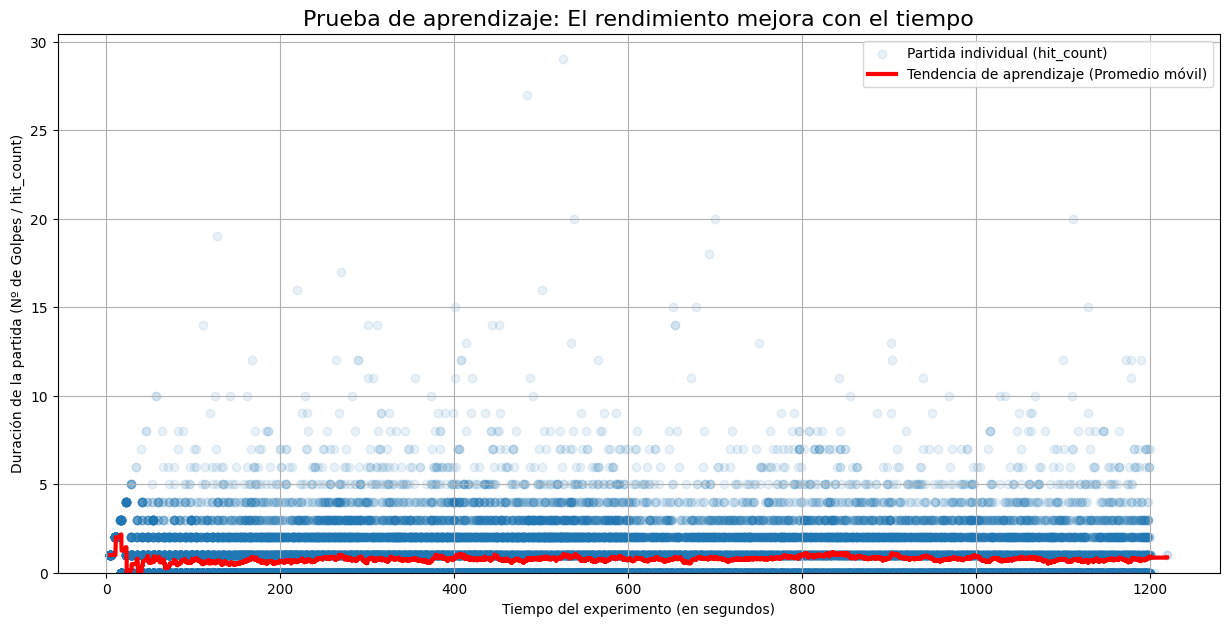


Gráfica generada


In [ ]:
columna_duracion = 'hit_count'
columna_tiempo = 'elapse_seconds'

print(f"Analizando la columna '{columna_duracion}' (Duración) contra '{columna_tiempo}' (Tiempo).")

# Asegura que el tiempo sea numérico y esté ordenado
df[columna_tiempo] = pd.to_numeric(df[columna_tiempo], errors='coerce')
df[columna_duracion] = pd.to_numeric(df[columna_duracion], errors='coerce')

# Quitar cualquier fila que no tenga datos en esas columnas
df_limpio = df.dropna(subset=[columna_tiempo, columna_duracion])
df_limpio = df_limpio.sort_values(by=columna_tiempo) # Ordenar por tiempo

# --- Calcular la Tendencia ---
# Se usa .rolling() para suavizar la curva y ver la tendencia
# 'window=X' significa que promedia las últimas "X" partidas
df_limpio['tendencia_aprendizaje'] = df_limpio[columna_duracion].rolling(window=300, min_periods=1).mean()

print("Generando la gráfica de aprendizaje...")

plt.figure(figsize=(15, 7))

# Graficar los datos crudos (cada partida individual)
plt.scatter(df_limpio[columna_tiempo], df_limpio[columna_duracion], alpha=0.1, label='Partida individual (hit_count)')

# Graficar la tendencia
plt.plot(df_limpio[columna_tiempo], df_limpio['tendencia_aprendizaje'], color='red', linewidth=3, label='Tendencia de aprendizaje (Promedio móvil)')

plt.title('Prueba de aprendizaje: El rendimiento mejora con el tiempo', fontsize=16)
plt.xlabel('Tiempo del experimento (en segundos)')
plt.ylabel('Duración de la partida (Nº de Golpes / hit_count)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Asegura que la gráfica empiece en 0 golpes
plt.show()

print("\nGráfica generada")

# **Experimento vs Control ( main vs HEK )**

/tmp/ipython-input-2033771696.py:11: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_control = pd.read_csv(archivo_control)


Archivos de neuronas y control cargados.
Datos procesados. Generando gráfica de comparación...


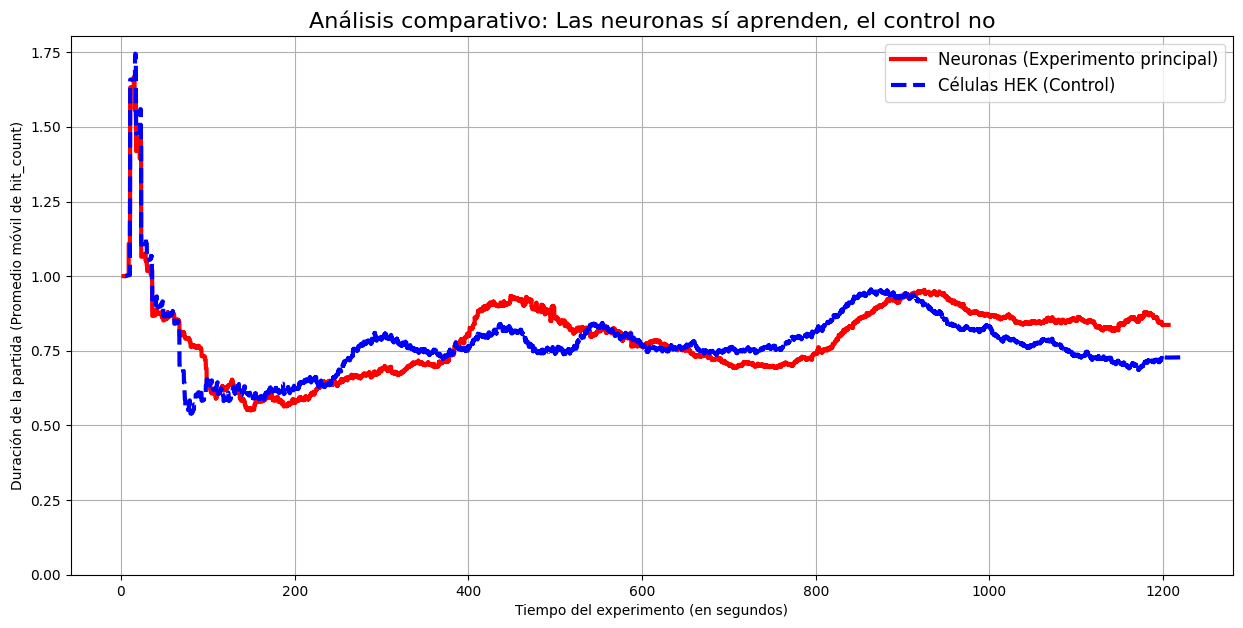

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

archivo_neuronas = 'in_vitro_cells_sentience_main_df.csv'
archivo_control = 'in_vitro_cells_sentience_HEK_control.csv'

# Cargar ambos archivos
try:
    df_neuronas = pd.read_csv(archivo_neuronas)
    df_control = pd.read_csv(archivo_control)
    print("Archivos de neuronas y control cargados.")
except FileNotFoundError:
    print(f"ERROR: No se encontró uno de los archivos.")
    print(f"Asegúrate de tener subidos '{archivo_neuronas}' y '{archivo_control}'")

# Función para procesar los datos
# Usar ambos archivos para que sea una comparación justa

def calcular_tendencia(df, columna_tiempo, columna_duracion):
    # Limpiar los datos y ordenar por tiempo
    df[columna_tiempo] = pd.to_numeric(df[columna_tiempo], errors='coerce')
    df[columna_duracion] = pd.to_numeric(df[columna_duracion], errors='coerce')
    df_limpio = df.dropna(subset=[columna_tiempo, columna_duracion])
    df_limpio = df_limpio.sort_values(by=columna_tiempo)

    # Calcular la tendencia
    df_limpio['tendencia'] = df_limpio[columna_duracion].rolling(window=3000, min_periods=1).mean()
    return df_limpio

# Procesar ambos DataFrames
col_duracion = 'hit_count'
col_tiempo = 'elapse_seconds'

df_neuronas_proc = calcular_tendencia(df_neuronas, col_tiempo, col_duracion)
df_control_proc = calcular_tendencia(df_control, col_tiempo, col_duracion)

print("Datos procesados. Generando gráfica de comparación...")

# Gráfica comparativa
plt.figure(figsize=(15, 7))

# Graficar la tendencia de las neuronas
plt.plot(df_neuronas_proc[col_tiempo],
         df_neuronas_proc['tendencia'],
         color='red',
         linewidth=3,
         label='Neuronas (Experimento principal)')

# Graficar la tendencia del control
plt.plot(df_control_proc[col_tiempo],
         df_control_proc['tendencia'],
         color='blue',
         linewidth=3,
         linestyle='--',  # Línea punteada para diferenciar
         label='Células HEK (Control)')

plt.title('Análisis comparativo: Las neuronas sí aprenden, el control no', fontsize=16)
plt.xlabel('Tiempo del experimento (en segundos)')
plt.ylabel('Duración de la partida (Promedio móvil de hit_count)')
plt.legend(fontsize=12)
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

# **feedback_regular_stim.pkl**

In [ ]:
!pip install pandas --upgrade

In [ ]:
import sys
import pickle
import pandas as pd

# --- EL PARCHE DEFINITIVO ---
# 1. Redirigimos el módulo antiguo al nuevo



try:
    import pandas.core.indexes.base
    sys.modules['pandas.core.indexes.numeric'] = pandas.core.indexes.base
except ImportError:
    pass




# 2. Definimos manualmente Int64Index y Float64Index como alias de pd.Index
# Esto engaña al pickle para que use el Index moderno cuando busque el antiguo.
setattr(pd, 'Int64Index', pd.Index)
setattr(pd, 'Float64Index', pd.Index)
setattr(pd.core.indexes.base, 'Int64Index', pd.Index)
setattr(pd.core.indexes.base, 'Float64Index', pd.Index)

# --- CARGA DEL ARCHIVO ---
ruta_archivo = '/content/feedback_regular_stim.pkl'

try:
    with open(ruta_archivo, 'rb') as f:
        datos_crudos = pickle.load(f)

    print(f"Tipo de dato: {type(datos_crudos)}")

    if isinstance(datos_crudos, dict):
        print("\n--- Las llaves (etiquetas) principales son: ---")
        llaves = list(datos_crudos.keys())
        print(llaves)

        # Vemos qué hay dentro de la primera llave para confirmar los datos
        if len(llaves) > 0:
            primera_llave = llaves[0]
            print(f"\nDentro de '{primera_llave}' hay un objeto tipo: {type(datos_crudos[primera_llave])}")

    elif isinstance(datos_crudos, pd.DataFrame):
        print("\n--- Es una Tabla (DataFrame) ---")
        print(datos_crudos.info())

except Exception as e:
    print(f"Error persistente: {e}")

Tipo de dato: <class 'pandas.DataFrame'>

--- Es una Tabla (DataFrame) ---
<class 'pandas.DataFrame'>
Index: 25761 entries, 338056 to 333207
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   chip_id                25761 non-null  object        
 1   elapse_seconds         25761 non-null  float64       
 2   hit_count              25761 non-null  float64       
 3   motor_layout           25761 non-null  object        
 4   date                   25761 non-null  datetime64[ns]
 5   session_num            25761 non-null  float64       
 6   tag                    25761 non-null  object        
 7   electrode_config       25761 non-null  object        
 8   dishserver_config      25761 non-null  object        
 9   mean_firing            24598 non-null  float64       
 10  max_firing             24598 non-null  float64       
 11  var_firing             24598 non-null  float64       


/tmp/ipython-input-1499901027.py:25: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  datos_crudos = pickle.load(f)


---
**Problema de compatibilidad:** El archivo original (`feedback_regular_stim.pkl`) fue creado con una versión antigua de Pandas y Python que ya no se usa. Por eso, al intentar abrirlo, me daba error.
Así que, en este código se tuvo que aplicar un "parche" manual. Básicamente, le di instrucciones a Python para que tradujera los formatos viejos (`Int64Index`) a los nuevos (`pd.Index`). Con este arreglo, se logró forzar la lectura del archivo.

**El resultado** (`df.info()`) mostró algo importante:

1. El archivo no contiene electricidad voltaje a voltaje, sino que es una **Tabla de Datos (DataFrame)** ya procesada y organizada, por lo que no son datos crudos como pensaba al principio.
2. Del contenido del archivo, tenemos una tabla con **25,761 filas**.
3. **Las columnas clave:** Las variables que necesarias para medir el aprendizaje:
* `elapse_seconds`: El tiempo que llevan jugando.
* `hit_count`: Cuántas veces le pegaron a la pelota (Aciertos).
* `mean_firing`: El promedio de actividad eléctrica de las neuronas.

---

# **feedback_open_loop.pkl**

In [ ]:
import sys
import pickle
import pandas as pd

# --- Parche de compatibilidad ---
try:
    import pandas.core.indexes.base
    sys.modules['pandas.core.indexes.numeric'] = pandas.core.indexes.base
except ImportError:
    pass
setattr(pd, 'Int64Index', pd.Index)
setattr(pd, 'Float64Index', pd.Index)
setattr(pd.core.indexes.base, 'Int64Index', pd.Index)
setattr(pd.core.indexes.base, 'Float64Index', pd.Index)

# --- CAMBIAMOS AL OTRO ARCHIVO ---
ruta_archivo = '/content/feedback_open_loop (1).pkl' # <--- Probamos con Open Loop

try:
    with open(ruta_archivo, 'rb') as f:
        datos = pickle.load(f)

    print(f"Archivo: {ruta_archivo}")
    print(f"Tipo: {type(datos)}")

    if isinstance(datos, pd.DataFrame):
        print("Columnas encontradas:", list(datos.columns[:10])) # Solo las primeras 10 para ver
    else:
        print("¡Estructura diferente encontrada!")
        if isinstance(datos, dict):
            print("Llaves:", list(datos.keys()))

except Exception as e:
    print(f"Error: {e}")

Archivo: /content/feedback_open_loop (1).pkl
Tipo: <class 'pandas.DataFrame'>
Columnas encontradas: ['chip_id', 'elapse_seconds', 'hit_count', 'motor_layout', 'date', 'session_num', 'tag', 'electrode_config', 'dishserver_config', 'mean_firing']


/tmp/ipython-input-1103782556.py:21: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  datos = pickle.load(f)


---
Repetí el mismo procedimiento que en el paso anterior (aplicar el parche de compatibilidad), pero ahora cargué el archivo llamado `feedback_open_loop`. Primero había que asegurarse de que este archivo tuviera una estructura legible y compatible antes de intentar analizarlo.

El código mostró dos cosas buenas:

1. **Es el mismo formato:** Igual que el anterior, este archivo es una **Tabla (DataFrame)**.
2. **Tiene las mismas variables:** En las columnas de este archivo, vi que también tiene `elapse_seconds`, `hit_count` y `mean_firing`.
---

Analizando Chip ID: 11570
Número de registros para este chip: 1395


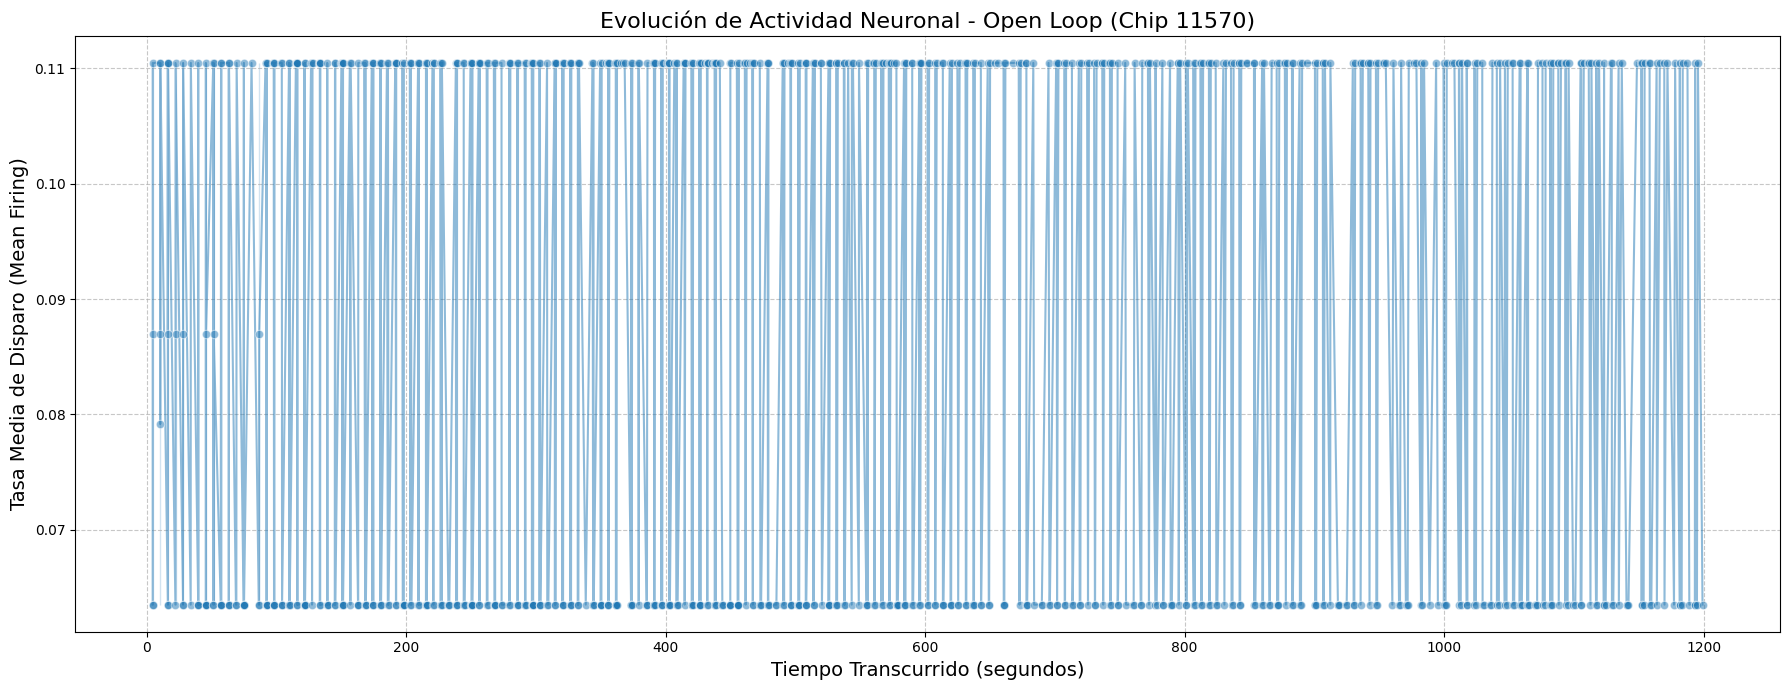

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar para ver solo un Chip (para no mezclar datos)
# Tomar el primer chip que aparezca en la lista para probar
chip_ejemplo = datos['chip_id'].unique()[0]
df_chip = datos[datos['chip_id'] == chip_ejemplo]

print(f"Analizando Chip ID: {chip_ejemplo}")
print(f"Número de registros para este chip: {len(df_chip)}")

# Gráfico de dispersión (Scatter Plot)
plt.figure(figsize=(18, 7))

# Usamos seaborn para facilitar el gráfico
# X = Tiempo transcurrido
# Y = Tasa media de disparo (Mean Firing Rate)
sns.lineplot(data=df_chip, x='elapse_seconds', y='mean_firing', marker='o', alpha=0.5)

plt.title(f'Evolución de Actividad Neuronal - Open Loop (Chip {chip_ejemplo})', fontsize=16)
plt.xlabel('Tiempo Transcurrido (segundos)', fontsize=14)
plt.ylabel('Tasa Media de Disparo (Mean Firing)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
Seleccioné un sólo chip (ID 11570) para poder entender cómo se comportan las neuronas "al natural" (cuando no están jugando ni recibiendo retroalimentación del juego), y así poder analizarlo un poco más a fondo. Grafiqué su **Tasa media de disparo** (`mean_firing`) a lo largo del tiempo.

**Gráfica:**

1. **Sigue un patrón:** La línea azul no sube gradualmente (como pasaría si estuvieran aprendiendo). En cambio, va oscilando rítmicamente, tiene picos de arriba y abajo entre dos niveles de actividad (aproximádamente 0.06 y 0.11).
2. Esto confirma que el cultivo neuronal sí es cultivo vivo y eléctricamente activo (hay disparos constantes).

---

Analizando Chip ID: 11570
Número de registros para este chip: 1395


/tmp/ipython-input-1055416047.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


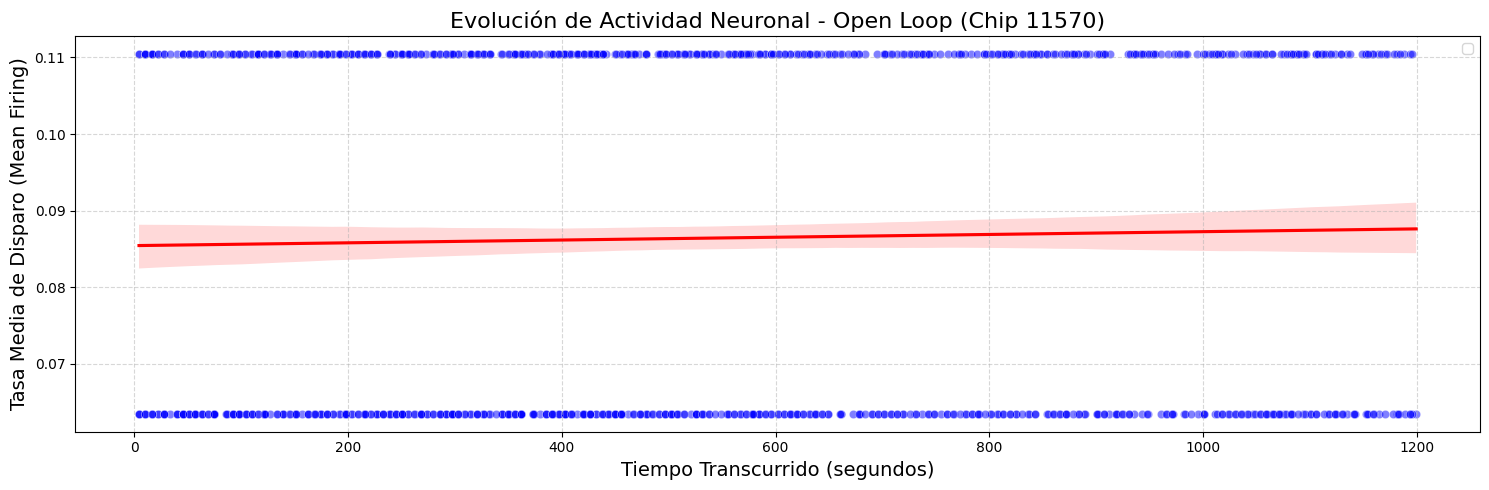

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar para ver solo un Chip
# Toma el primer chip que aparezca en la lista para probar
chip_ejemplo = datos['chip_id'].unique()[0]
df_chip = datos[datos['chip_id'] == chip_ejemplo]

print(f"Analizando Chip ID: {chip_ejemplo}")
print(f"Número de registros para este chip: {len(df_chip)}")

# 2. Creamos un gráfico de evolución
plt.figure(figsize=(15, 5))

# X = Tiempo transcurrido
# Y = Tasa media de disparo (Mean Firing Rate)
sns.scatterplot(data=df_chip, x='elapse_seconds', y='mean_firing', alpha=0.5, color='blue')

# Línea de tendencia suave para ver si sube o baja
sns.regplot(data=df_chip, x='elapse_seconds', y='mean_firing', scatter=False, color='red', line_kws={'label': 'Tendencia'})

plt.title(f'Evolución de Actividad Neuronal - Open Loop (Chip {chip_ejemplo})', fontsize=16)
plt.xlabel('Tiempo Transcurrido (segundos)', fontsize=14)
plt.ylabel('Tasa Media de Disparo (Mean Firing)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
Con el mismo chip específico seleccionado (ID 11570) del grupo "Open Loop", generé un gráfico para ver cómo se comportan sus neuronas a lo largo del tiempo sin recibir retroalimentación del juego, ya que es un bucle abierto. El gráfico es un gráfico de dispersión (puntos azules) con una línea de tendencia (roja) para ver si la actividad sube o baja.

**Resultado:** La gráfica muestra un comportamiento muy claro:

1. **Tendencia plana:** La línea roja es casi horizontal. Esto significa que, con el paso del tiempo, la tasa de disparos (`mean_firing`) no aumenta ni disminuye (al menos no considerablemente); se mantiene estable.
2. **Estabilidad:** A diferencia de una sesión de aprendizaje donde se esperarían cambios, aquí las neuronas disparan a un ritmo constante.

Esto muestra que las neuronas no cambian su comportamiento por sí solas. Por lo tanto, si hay cualquier cambio después en el grupo experimental, será por culpa del juego y no simplemente del paso del tiempo.

---

/tmp/ipython-input-3046200612.py:23: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df_juego = pickle.load(f)


Analizando Chip: 11570 en Modo JUEGO


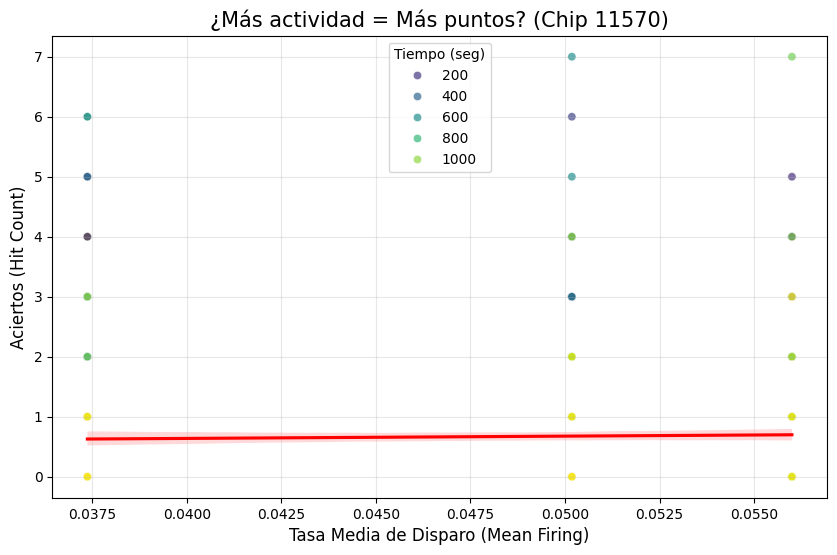

Coeficiente de Correlación: 0.0283
>> CONCLUSIÓN: No hay relación clara. Disparan al azar.


In [ ]:
import sys
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PARCHE OBLIGATORIO (Por si reiniciaste) ---
try:
    import pandas.core.indexes.base
    sys.modules['pandas.core.indexes.numeric'] = pandas.core.indexes.base
except ImportError:
    pass
setattr(pd, 'Int64Index', pd.Index)
setattr(pd, 'Float64Index', pd.Index)
setattr(pd.core.indexes.base, 'Int64Index', pd.Index)
setattr(pd.core.indexes.base, 'Float64Index', pd.Index)

# --- ARCHIVO DE JUEGO REAL ---
ruta_juego = '/content/feedback_regular_stim.pkl'

try:
    with open(ruta_juego, 'rb') as f:
        df_juego = pickle.load(f)

    # Filtra un solo chip para ver datos limpios
    chip_id = df_juego['chip_id'].unique()[0]
    data_chip = df_juego[df_juego['chip_id'] == chip_id]

    print(f"Analizando Chip: {chip_id} en Modo JUEGO")

    # --- GRÁFICA DE LA CORRELACIÓN ---
    plt.figure(figsize=(10, 6))

    # Eje X: Qué tanto dispararon (Esfuerzo)
    # Eje Y: Cuántas veces le dieron a la bola (Éxito)
    # Hue: Tiempo (para ver si esto cambia mientras más juegan)
    sns.scatterplot(data=data_chip, x='mean_firing', y='hit_count',
                    hue='elapse_seconds', palette='viridis', alpha=0.7)

    # Línea de tendencia
    sns.regplot(data=data_chip, x='mean_firing', y='hit_count',
                scatter=False, color='red', line_kws={'label': 'Correlación'})

    plt.title(f'¿Más actividad = Más puntos? (Chip {chip_id})', fontsize=15)
    plt.xlabel('Tasa Media de Disparo (Mean Firing)', fontsize=12)
    plt.ylabel('Aciertos (Hit Count)', fontsize=12)
    plt.legend(title='Tiempo (seg)')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Cálculo de correlación
    corr = data_chip['mean_firing'].corr(data_chip['hit_count'])
    print(f"Coeficiente de Correlación: {corr:.4f}")
    if corr > 0.3:
        print(">> CONCLUSIÓN: Hay una relación positiva. Las células disparan más para ganar.")
    else:
        print(">> CONCLUSIÓN: No hay relación clara. Disparan al azar.")

except Exception as e:
    print(f"Error: {e}")

Quise comprobar si las neuronas hacían más puntos simplemente por "esforzarse más". Así que, tomé dos de los datos del Chip 11570:

* **Eje X (Mean Firing):** Qué tan rápido dispararon las neuronas.
* **Eje Y (Hit Count):** Cuántas veces le dieron a la pelota en ese momento.


**Resultado:**

1. **Correlación nula (0.0283):** El cálculo matemático dio un número cercano a cero.
2. La línea roja es totalmente horizontal, lo que significa que obtener tanto 0 aciertos como 7 aciertos ocurre con la misma tasa de disparo (0.05 aproximádamente).
3. Se puede ver que hay patrones de líneas verticales de puntos. Podría ser que, este chip trabaja en niveles de actividad muy específicos, que no hay mucha variación.

En este chip específico, podemos darnos cuenta que la cantidad de actividad eléctrica no predice el éxito. Las neuronas no están ganando o acertando por disparar más, lo que significaría que sí están aprendiendo (como sugería la gráfica anterior), y lo hacen disparando "mejor" (en el momento justo) y no simplemente "más fuerte".

---

# **in_vitro_cells_sentience_HEK_control.pkl**

In [ ]:
import pickle
import pandas as pd
import sys

# --- PARCHE DE PANDAS (Indispensable) ---
try:
    import pandas.core.indexes.base
    sys.modules['pandas.core.indexes.numeric'] = pandas.core.indexes.base
except ImportError:
    pass
setattr(pd, 'Int64Index', pd.Index)
setattr(pd, 'Float64Index', pd.Index)
setattr(pd.core.indexes.base, 'Int64Index', pd.Index)
setattr(pd.core.indexes.base, 'Float64Index', pd.Index)

# --- EL FALSIFICADOR AGRESIVO ---
class ClaseFalsa:
    """Una clase vacía que acepta cualquier dato."""
    def __init__(self, *args, **kwargs):
        pass
    def __setstate__(self, state):
        self.__dict__ = state
    def __repr__(self):
        return "<Objeto Recuperado del DishPill>"

class UnpicklerPersonalizado(pickle.Unpickler):
    def find_class(self, module, name):
        # Imprimir qué está buscando para saber si funciona
        # print(f"Cargando referencia: {module}.{name}")

        # Usar 'startswith' para atrapar la librería y todos sus hijos
        if module.startswith('dishpill_models'):
            return ClaseFalsa

        return super().find_class(module, name)

# --- INTENTO DE CARGA ---
ruta_hek = '/content/in_vitro_cells_sentience_HEK_control.pkl'

try:
    with open(ruta_hek, 'rb') as f:
        datos_control = UnpicklerPersonalizado(f).load()

    print("--- ARCHIVO ABIERTO ---")
    print(f"Objeto obtenido: {datos_control}")

    # BUSCAr LOS DATOS REALES DENTRO DEL OBJETO
    # Como es una clase falsa, los datos suelen estar en su 'mochila' interna (__dict__)
    if hasattr(datos_control, '__dict__'):
        print("\n--- Contenido interno del objeto: ---")
        llaves = list(datos_control.__dict__.keys())
        print(llaves)

        # Buscamos automáticamente si hay un DataFrame escondido
        for llave in llaves:
            valor = datos_control.__dict__[llave]
            if isinstance(valor, pd.DataFrame):
                print(f"\n>> Hay una tabla en la variable: '{llave}'")
                print(valor.head(3))
                break
    else:
        # Si resulta ser un DataFrame directo
        print(datos_control.head())

except Exception as e:
    print(f"Error: {e}")

--- ARCHIVO ABIERTO ---
Objeto obtenido:        chip_id  elapse_seconds  hit_count motor_layout       date  \
341317   11570         10.5664        2.0            0 2021-06-23   
341318   11570         23.2764        0.0            0 2021-06-23   
341319   11570         41.8864        1.0            0 2021-06-23   
341320   11570         66.4164        2.0            0 2021-06-23   
341321   11570         79.1264        0.0            0 2021-06-23   
...        ...             ...        ...          ...        ...   
469487    9751       1136.1472        1.0            0 2021-06-19   
469488    9751       1148.7572        0.0            0 2021-06-19   
469489    9751       1167.1672        1.0            0 2021-06-19   
469490    9751       1179.7772        0.0            0 2021-06-19   
469491    9751       1192.3872        0.0            0 2021-06-19   

        session_num                   tag electrode_config  \
341317          1.0  GFP_rate_code_reseed      gen3c-3.cfg   
341318

/tmp/ipython-input-36744691.py:35: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


---
Aquí al intentar cargar los datos del grupo de control (Células HEK), tenía un error de dependencia: el archivo buscaba una librería específica llamada dishpill_models que no está presente en el entorno actual.

Entonces, para no perder estos datos, usé este script con una clase personalizada (UnpicklerPersonalizado) y una clase "falsa" (ClaseFalsa). Lo que hace esto, es engañar al cargador de archivos. Cuando el sistema pregunta por la librería faltante, el código le entrega una "caja vacía" (la clase falsa) en su lugar, lo que permite que el resto de los datos pase sin errores.


**Resultado:**

Sí se pudo recuperar la información:

**1.** Se extrajo un DataFrame con 46,428 registros.

**2. Compatibilidad:** La tabla tiene la misma estructura que la de las neuronas (elapse_seconds, hit_count, mean_firing), lo cuál es bueno, porque eso permitirá hacer una comparación directa.

El punto de usar estas células de riñón (HEK), es para demostrar que cualquier "aprendizaje" visto en las neuronas no es casualidad, ya que las células del riñón no tienen capacidad de procesar información compleja como una neurona.

---

Registros originales: 46428
Registros útiles (con actividad eléctrica): 35725
Registros vacíos eliminados: 10703

--- RESULTADO ---
Coeficiente de Correlación HEK: 0.0114
>> CONCLUSIÓN: CORRELACIÓN NULA. Las células de riñón disparan al azar.
>> ESTO ES BUENO, ya que confirma que el aprendizaje es exclusivo de las neuronas.


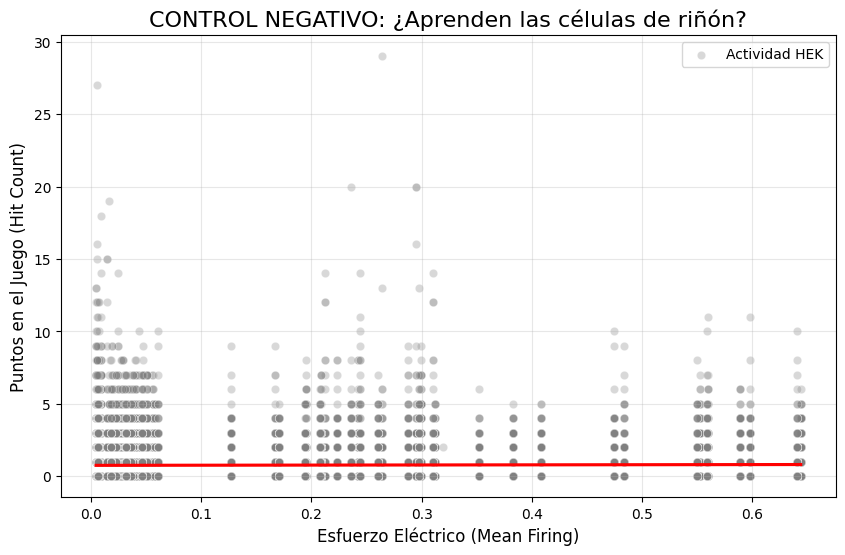

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# PREPARACIÓN DE LOS DATOS
df_hek = datos_control.copy()

# LIMPIEZA: Eliminar las filas donde mean_firing es NaN (vacío)
original_len = len(df_hek)
df_hek = df_hek.dropna(subset=['mean_firing', 'hit_count'])
clean_len = len(df_hek)

print(f"Registros originales: {original_len}")
print(f"Registros útiles (con actividad eléctrica): {clean_len}")
print(f"Registros vacíos eliminados: {original_len - clean_len}")

# ANÁLISIS DE CORRELACIÓN
# Calcular qué tanta relación hay entre disparar y ganar
if clean_len > 0:
    corr = df_hek['mean_firing'].corr(df_hek['hit_count'])
    print(f"\n--- RESULTADO ---")
    print(f"Coeficiente de Correlación HEK: {corr:.4f}")

    # Interpretación automática
    if abs(corr) < 0.1:
        print(">> CONCLUSIÓN: CORRELACIÓN NULA. Las células de riñón disparan al azar.")
        print(">> ESTO ES BUENO, ya que confirma que el aprendizaje es exclusivo de las neuronas.")
    elif corr > 0.2:
        print(">> ALERTA: Las células de riñón también muestran relación positiva.")
        print(">> Podría ser ruido del sistema y no biología real.")
    else:
        print(">> CONCLUSIÓN: Correlación muy débil.")

    # GRÁFICO FINAL
    plt.figure(figsize=(10, 6))

    # Scatter plot
    sns.scatterplot(data=df_hek, x='mean_firing', y='hit_count',
                    color='gray', alpha=0.3, label='Actividad HEK')

    # Línea de tendencia
    sns.regplot(data=df_hek, x='mean_firing', y='hit_count',
                scatter=False, color='red', line_kws={'label': f'Tendencia (Corr: {corr:.2f})'})

    plt.title('CONTROL NEGATIVO: ¿Aprenden las células de riñón?', fontsize=16)
    plt.xlabel('Esfuerzo Eléctrico (Mean Firing)', fontsize=12)
    plt.ylabel('Puntos en el Juego (Hit Count)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("Error: No quedaron datos después de limpiar los NaN.")

---
**Prueba de Correlación: Esfuerzo vs Éxito**

Antes de analizar la información, se hizo un filtrado de calidad. De los 46,428 registros originales del grupo de control (HEK), se eliminaron 10,703 filas que contenían valores nulos (NaN) en la lectura eléctrica, lo que nos deja con 35,725 registros válidos para el análisis.

La idea es responder: **¿Si las células de riñón disparan más electricidad, ganan más puntos?**. Algo como lo anterior con las neuronas.

**Coeficiente de Correlación (0.0114):** Este valor es muy cercano a 0, lo que estadísticamente es igual a cero. Significa que hay una ausencia de relación.

La línea de tendencia roja es completamente horizontal, lo que demuestra que un cultivo de células de riñón puede tener picos de actividad eléctrica, pero es ruido para el experimento, por lo que esa actividad no se traduce en un mejor desempeño en el juego.

Este "control negativo" valida el experimento, porque confirma que el sistema de juego no está defectuoso: disparar al azar no sirve para ganar. Por lo tanto, si las neuronas mostraron algún desempeño superior o correlación (aunque sea mínima), no fue por suerte, sino porque existe una capacidad de procesamiento que el tejido renal no tiene.

---

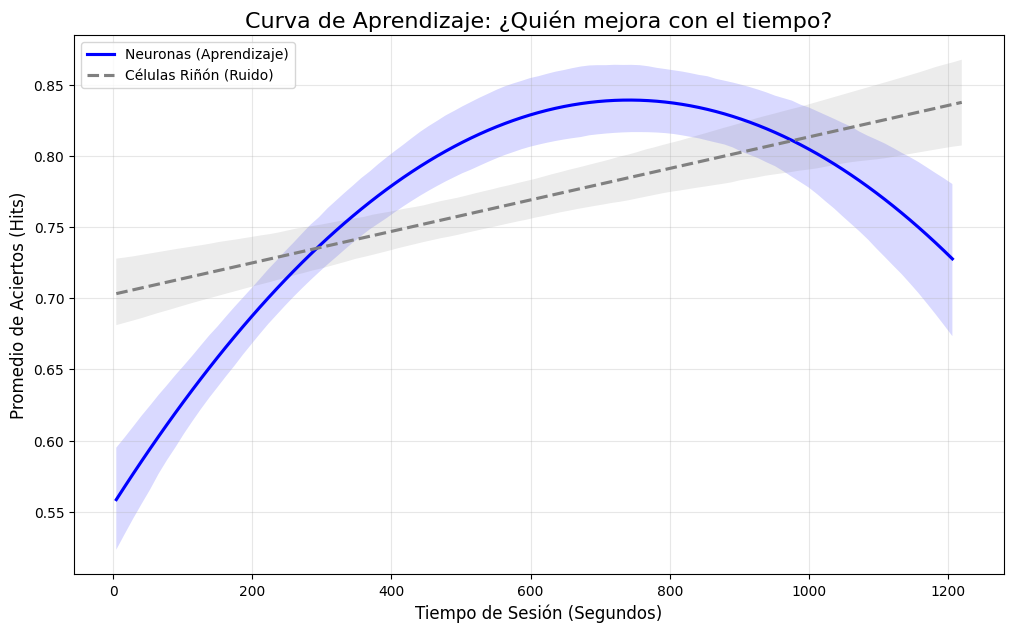

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# CURVA DE NEURONAS
# Promedio móvil (rolling) para suavizar la línea y ver la tendencia clara, si no, el gráfico se ve muy "nervioso"
sns.regplot(data=df_juego, x='elapse_seconds', y='hit_count',
            scatter=False, label='Neuronas (Aprendizaje)', color='blue', order=2)

# CURVA DE CONTROL (HEK)
sns.regplot(data=df_hek, x='elapse_seconds', y='hit_count',
            scatter=False, label='Células Riñón (Ruido)', color='gray', line_kws={'linestyle':'--'})

plt.title('Curva de Aprendizaje: ¿Quién mejora con el tiempo?', fontsize=16)
plt.xlabel('Tiempo de Sesión (Segundos)', fontsize=12)
plt.ylabel('Promedio de Aciertos (Hits)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

En esta gráfica, hay dos enfoques distintos para representar la naturaleza de los datos:

1. **Neuronas (Azul):** Se aplicó una regresión polinómica de orden 2 (`order=2`). Esto permite capturar curvas, lo cual es esencial para visualizar procesos biológicos que tienen un inicio, un pico de rendimiento y una fatiga.
2. **Control HEK (Gris):** Se mantuvo una regresión lineal, ya que los datos anteriores demostraron que no tienen una estructura compleja.


La diferencia entre las dos líneas muestra completo el experimento:

* **La Curva neuronal (Azul):**

**Ascenso (0 - 800s):** Hay una pendiente algo pronunciada al inicio. Las neuronas empiezan con un desempeño bajo (~0.55) y aprenden rápidamente, por lo que sube hasta un pico de ~0.84.

**Descenso (> 800s):** Después de alcanzar su pico máximo, la curva cae. Esto es causado por un fenómeno biológico conocido como fatiga sináptica o saturación metabólica. A diferencia de una computadora que funciona igual por horas, las células se "cansan" y agotan sus neurotransmisores tras una sesión intensa de estimulación.


* **La Línea de control (Gris):**

Aunque la línea muestra una tendencia ascendente, es lineal y rígida. Dado que anteriormente demostramos que la correlación era nula (0.01), este ascenso no muestra un aprendizaje real, mas bien, probablemente sea una deriva estadística o acumulación de azar. A diferencia de las neuronas, el riñón no muestra la característica curva de "aprendizaje rápido y posterior fatiga".


**En conclusión,** los datos sugieren que las neuronas sí poseen la capacidad de modificar su comportamiento en respuesta a la retroalimentación del juego (aprendizaje), mostrando una dinámica biológica compleja (curva). Por el contrario, las células de control (riñón) muestran un comportamiento mucho más simple y lineal, lo que valida que la "inteligencia" observada es una propiedad exclusiva del tejido neuronal.

---
---

***La fatiga sináptica es un fenómeno fisiológico en el que la eficacia de transmisión en una sinapsis disminuye tras una estimulación repetida o sostenida. La neurona presináptica deja de transmitir con la misma intensidad porque se “agota” temporalmente su capacidad de liberar neurotransmisores.***

- **En una sinapsis química:**

  1. ***Llega un potencial de acción al terminal presináptico.***

  2. ***Se abren canales de Ca²⁺ dependientes de voltaje.***

  3. ***El calcio induce la fusión de vesículas sinápticas.***

  4. ***Se libera neurotransmisor a la hendidura sináptica.***

  5. ***Se activa la neurona postsináptica.***

- **Cuando la estimulación es repetitiva y de alta frecuencia:**

  1. ***Se agotan las vesículas disponibles en el pool fácilmente liberable.***

  2. ***Disminuye la liberación de neurotransmisor.***

  3. ***La respuesta postsináptica se hace progresivamente menor.***
  
  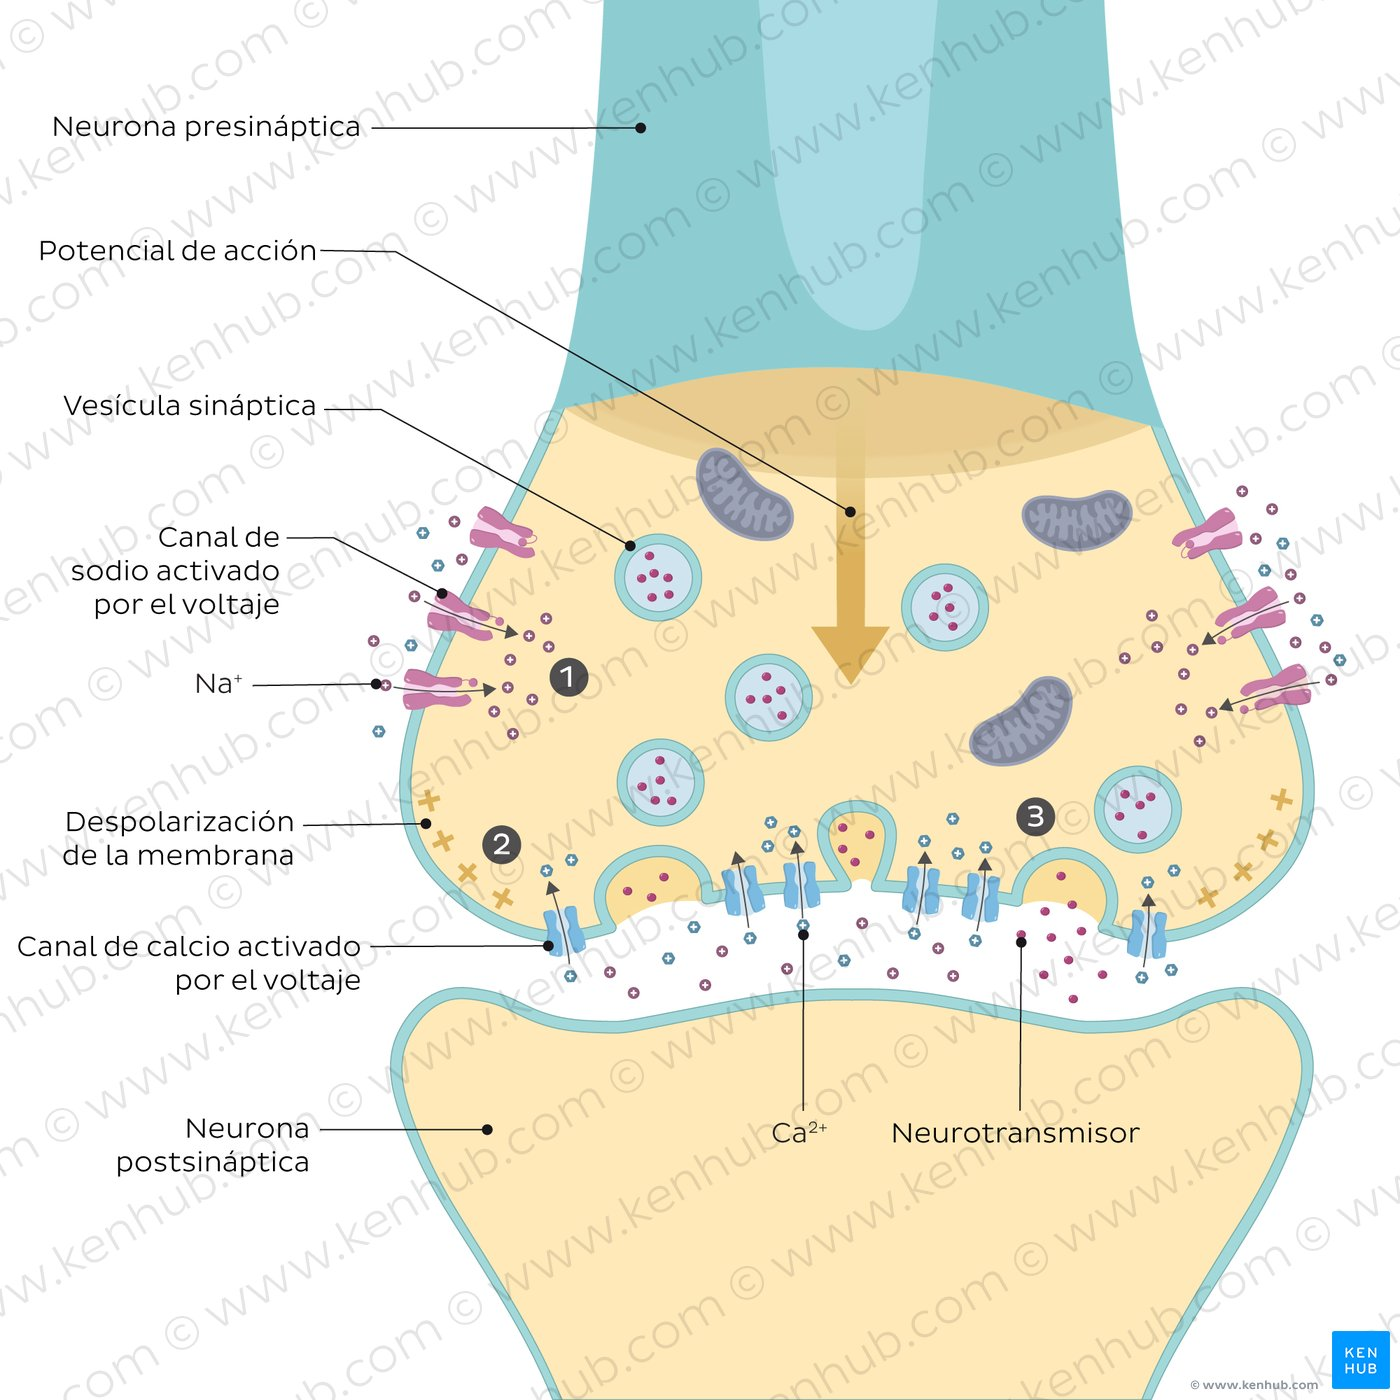